# 1. Libraries & Dependencies

In [1]:
# ── Cell 1: Imports & Setup ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats import pearsonr, spearmanr, pointbiserialr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
# ── Cell 2: Load Dataset ─────────────────────────────────────────────────────
df = pd.read_csv('titanic.csv')

print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: 891 rows × 12 columns
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [40]:
# ── Display 10 samples where Survived = True and 10 where Survived = False ──

survived_true = df[df['Survived'] == 0].sample(10, random_state=42)
survived_false = df[df['Survived'] == 1].sample(10, random_state=42)

print("10 Samples where Survived = True")
display(survived_true)

print("\n10 Samples where Survived = False")
display(survived_false)

10 Samples where Survived = True


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_Prefix,Age_Group
312,313,0,2,"Lahtinen, Mrs. William (Anna Sylfven)",female,26.0,1,1,250651,26.0000,NaN,S,NUMERIC,Adult\n(19-35)
124,125,0,1,"White, Mr. Percival Wayland",male,54.0,0,1,35281,77.2875,D26,S,NUMERIC,Middle-aged\n(36-60)
783,784,0,3,"Johnston, Mr. Andrew G",male,NaN,1,2,W./C. 6607,23.4500,NaN,S,W./C.,NaN
167,168,0,3,"Skoog, Mrs. William (Anna Bernhardina Karlsson)",female,45.0,1,4,347088,27.9000,NaN,S,NUMERIC,Middle-aged\n(36-60)
772,773,0,2,"Mack, Mrs. (Mary)",female,57.0,0,0,S.O./P.P. 3,10.5000,E77,S,S.O./P.P.,Middle-aged\n(36-60)
798,799,0,3,"Ibrahim Shawah, Mr. Yousseff",male,30.0,0,0,2685,7.2292,NaN,C,NUMERIC,Adult\n(19-35)
132,133,0,3,"Robins, Mrs. Alexander A (Grace Charity Laury)",female,47.0,1,0,A/5. 3337,14.5000,NaN,S,A/5.,Middle-aged\n(36-60)
606,607,0,3,"Karaic, Mr. Milan",male,30.0,0,0,349246,7.8958,NaN,S,NUMERIC,Adult\n(19-35)
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.5500,NaN,S,CA.,NaN
601,602,0,3,"Slabenoff, Mr. Petco",male,NaN,0,0,349214,7.8958,NaN,S,NUMERIC,NaN



10 Samples where Survived = False


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_Prefix,Age_Group
604,605,1,1,"Homer, Mr. Harry (""Mr E Haven"")",male,35.0,0,0,111426,26.5500,NaN,C,NUMERIC,Adult\n(19-35)
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,PC,Teen\n(13-18)
307,308,1,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17.0,1,0,PC 17758,108.9000,C65,C,PC,Teen\n(13-18)
107,108,1,3,"Moss, Mr. Albert Johan",male,NaN,0,0,312991,7.7750,NaN,S,NUMERIC,NaN
329,330,1,1,"Hippach, Miss. Jean Gertrude",female,16.0,0,1,111361,57.9792,B18,C,NUMERIC,Teen\n(13-18)
708,709,1,1,"Cleaver, Miss. Alice",female,22.0,0,0,113781,151.5500,NaN,S,NUMERIC,Adult\n(19-35)
458,459,1,2,"Toomey, Miss. Ellen",female,50.0,0,0,F.C.C. 13531,10.5000,NaN,S,F.C.C.,Middle-aged\n(36-60)
453,454,1,1,"Goldenberg, Mr. Samuel L",male,49.0,1,0,17453,89.1042,C92,C,NUMERIC,Middle-aged\n(36-60)
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,NaN,S,NUMERIC,Adult\n(19-35)
56,57,1,2,"Rugg, Miss. Emily",female,21.0,0,0,C.A. 31026,10.5000,NaN,S,C.A.,Adult\n(19-35)


# 2. Missing/Duplicate Values Analysis

## 2.1 Missing Values Analysis

In [3]:
# ── Cell 3: Missing Value Summary Table ─────────────────────────────────────
missing_count = df.isnull().sum()
missing_pct   = df.isnull().mean() * 100
dtype_col     = df.dtypes

missing_summary = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing %'     : missing_pct.round(2),
    'Data Type'     : dtype_col
}).sort_values('Missing %', ascending=False)

# Highlight columns that actually have missing values
missing_summary_filtered = missing_summary[missing_summary['Missing Count'] > 0]

print(f'Total columns with missing values: {len(missing_summary_filtered)}')
missing_summary_filtered

Total columns with missing values: 3


,Missing Count,Missing %,Data Type
Cabin,687,77.10,object
Age,177,19.87,float64
Embarked,2,0.22,object


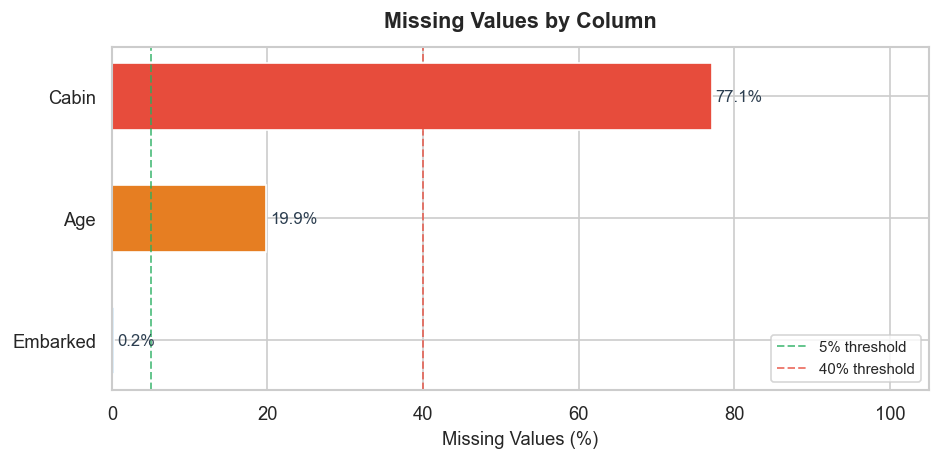

In [4]:
# ── Cell 4: Bar Chart — Missing % per Column ────────────────────────────────
cols_with_missing = missing_summary_filtered.index.tolist()
pcts              = missing_summary_filtered['Missing %'].values

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['#e74c3c' if p > 40 else '#e67e22' if p > 10 else '#3498db' for p in pcts]
bars   = ax.barh(cols_with_missing, pcts, color=colors, edgecolor='white', height=0.55)

# Annotate bars
for bar, pct in zip(bars, pcts):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=10, color='#2c3e50')

# Reference lines
for threshold, label, color in [(5, '5%', '#27ae60'), (40, '40%', '#e74c3c')]:
    ax.axvline(threshold, linestyle='--', linewidth=1.2, color=color, alpha=0.7, label=f'{label} threshold')

ax.set_xlabel('Missing Values (%)', fontsize=11)
ax.set_title('Missing Values by Column', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 105)
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

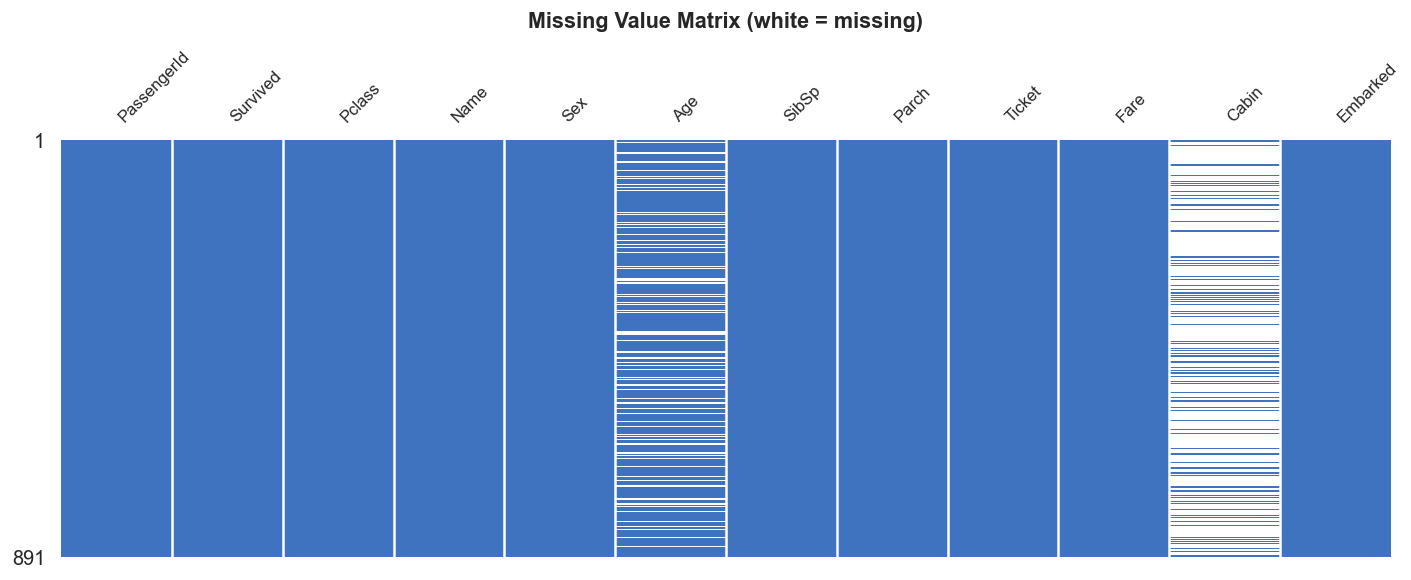

In [5]:
# ── Cell 5: missingno — Matrix Plot  ──────────────────
fig, ax = plt.subplots(figsize=(12, 5))
msno.matrix(df, ax=ax, sparkline=True, fontsize=10, color=(0.25, 0.45, 0.75))
ax.set_title('Missing Value Matrix (white = missing)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

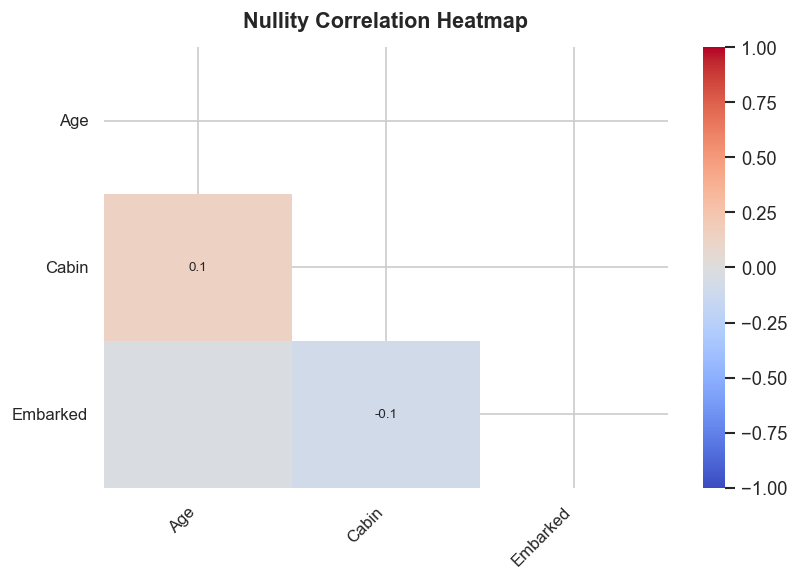

In [6]:
# ── Cell 6: missingno — Heatmap (correlation of missingness) ─────────────────
fig, ax = plt.subplots(figsize=(7, 5))
msno.heatmap(df, ax=ax, fontsize=10, cmap='coolwarm')
ax.set_title('Nullity Correlation Heatmap', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

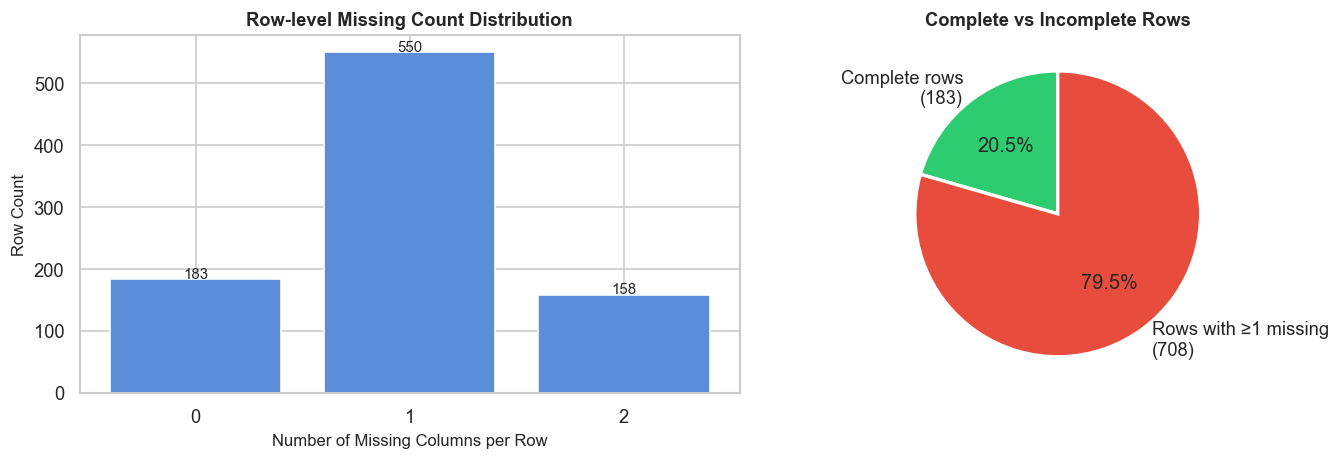

In [7]:
# ── Cell 7: Row-level Missingness Distribution ───────────────────────────────
# How many rows have 0, 1, 2, … missing values?

row_missing = df.isnull().sum(axis=1)
row_missing_counts = row_missing.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left: bar chart
axes[0].bar(row_missing_counts.index.astype(str), row_missing_counts.values,
            color='#5b8dd9', edgecolor='white')
axes[0].set_xlabel('Number of Missing Columns per Row', fontsize=10)
axes[0].set_ylabel('Row Count', fontsize=10)
axes[0].set_title('Row-level Missing Count Distribution', fontsize=11, fontweight='bold')
for i, v in enumerate(row_missing_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=9)

# --- Right: pie chart
complete = (row_missing == 0).sum()
incomplete = (row_missing > 0).sum()
axes[1].pie([complete, incomplete],
            labels=[f'Complete rows\n({complete})', f'Rows with ≥1 missing\n({incomplete})'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Complete vs Incomplete Rows', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# ── Cell 8: Imputation Strategy Recommendation ───────────────────────────────
# Rule-based suggestion based on missing % and dtype

def suggest_imputation(col, pct, dtype):
    if pct == 0:
        return 'No action needed'
    if pct >= 70:
        return '🔴 Critical'
    if pct <= 10:
        return '🟢 Low'
    return '🟡 Medium'

strategy_df = missing_summary_filtered.copy()
strategy_df['Severity'] = [
    suggest_imputation(col, row['Missing %'], str(row['Data Type']))
    for col, row in strategy_df.iterrows()
]

strategy_df[['Missing Count', 'Missing %', 'Severity']]

,Missing Count,Missing %,Severity
Cabin,687,77.10,🔴 Critical
Age,177,19.87,🟡 Medium
Embarked,2,0.22,🟢 Low


## 2.2 Duplicate Values Analysis

In [9]:
# ── Cell 9: Duplicate Row Summary ──────────────────────────────────────────
# Overall duplicate rows (based on all columns)

total_rows = len(df)

dup_mask = df.duplicated()
# count of duplicate rows (excluding the first occurrence)
dup_rows = int(dup_mask.sum())
unique_rows = total_rows - dup_rows

dup_pct = (dup_rows / total_rows * 100) if total_rows else 0

summary = pd.DataFrame({
    'Total Rows'    : [total_rows],
    'Unique Rows'   : [unique_rows],
    'Duplicate Rows': [dup_rows],
    'Duplicate %'   : [round(dup_pct, 2)]
})

print(f"Duplicate rows (exact duplicates across all columns): {dup_rows} ({dup_pct:.2f}%)")
summary


Duplicate rows (exact duplicates across all columns): 0 (0.00%)


,Total Rows,Unique Rows,Duplicate Rows,Duplicate %
0,891,891,0,0.0


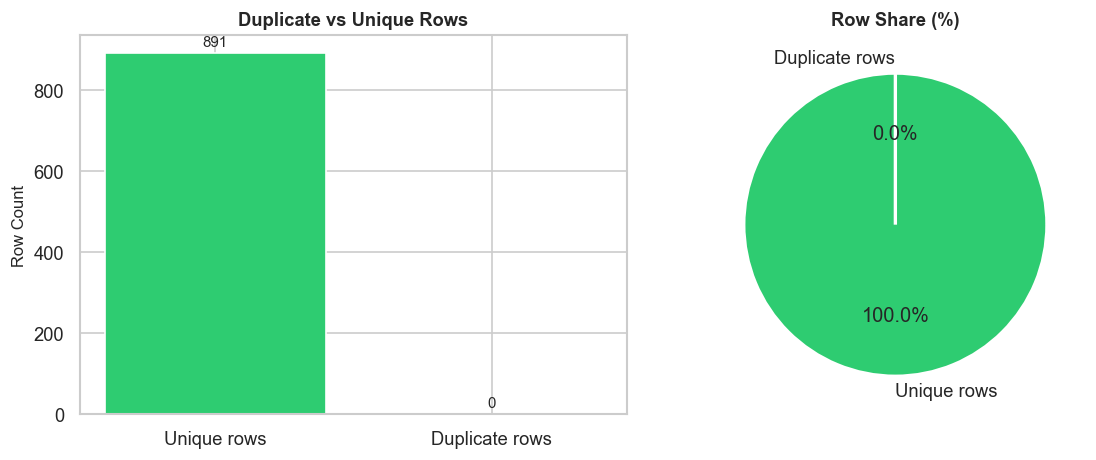

In [10]:
# ── Cell 10: Duplicate vs Unique Rows (Bar + Pie) ───────────────────────
# Visual summary of duplicates

labels = ['Unique rows', 'Duplicate rows']
values = [unique_rows, dup_rows]
colors = ['#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(labels, values, color=colors, edgecolor='white')
axes[0].set_title('Duplicate vs Unique Rows', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Row Count', fontsize=10)
for i, v in enumerate(values):
    axes[0].text(i, v + max(values)*0.02, str(v), ha='center', fontsize=9)

# Pie chart
axes[1].pie(values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Row Share (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


# 3. Numerical Features Analysis

In [11]:
# ── Cell 11: Identify Column Types ────────────────────────────────────────────
num_cols  = df.select_dtypes(include=['number']).columns.tolist()
cat_cols  = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f' Numerical columns  ({len(num_cols)}): {num_cols}')
print(f' Categorical columns ({len(cat_cols)}): {cat_cols}')

# Visual summary table
type_df = pd.DataFrame({
    'Column'   : df.columns,
    'Dtype'    : df.dtypes.values,
    'Type'     : ['Numerical' if c in num_cols else 'Categorical' for c in df.columns],
    'Nunique'  : [df[c].nunique() for c in df.columns],
    'Missing %': [round(df[c].isnull().mean() * 100, 2) for c in df.columns]
})
type_df

 Numerical columns  (7): ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
 Categorical columns (5): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


,Column,Dtype,Type,Nunique,Missing %
0,PassengerId,int64,Numerical,891,0.00
1,Survived,int64,Numerical,2,0.00
2,Pclass,int64,Numerical,3,0.00
3,Name,object,Categorical,891,0.00
4,Sex,object,Categorical,2,0.00
5,Age,float64,Numerical,88,19.87
6,SibSp,int64,Numerical,7,0.00
7,Parch,int64,Numerical,7,0.00
8,Ticket,object,Categorical,681,0.00
9,Fare,float64,Numerical,248,0.00


In [12]:
# ── Cell 12: Drop non-analytical numerical columns ────────────────────────────
# PassengerId is just a row index; Survived is the binary target 
drop_from_num = ['PassengerId', 'Survived']
num_cols = [c for c in num_cols if c not in drop_from_num]

print(f'Numerical features for analysis ({len(num_cols)}): {num_cols}')

Numerical features for analysis (5): ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [13]:
# ── Cell 13: Descriptive Statistics Table ─────────────────────────────────────
def extended_stats(df, cols):
    rows = []
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = ((s < lower) | (s > upper)).sum()
        rows.append({
            'Column'   : col,
            'Count'    : len(s),
            'Mean'     : round(s.mean(), 2),
            'Median'   : round(s.median(), 2),
            'Std'      : round(s.std(), 2),
            'Min'      : round(s.min(), 2),
            'Max'      : round(s.max(), 2),
            'Q1'       : round(q1, 2),
            'Q3'       : round(q3, 2),
            'IQR'      : round(iqr, 2),
            'Skewness' : round(s.skew(), 2),
            'Kurtosis' : round(s.kurt(), 2),
            'Outliers' : n_outliers
        })
    return pd.DataFrame(rows).set_index('Column')

stats_df = extended_stats(df, num_cols)
stats_df

,Count,Mean,Median,Std,Min,Max,Q1,Q3,IQR,Skewness,Kurtosis,Outliers
Column,,,,,,,,,,,,
Pclass,891,2.31,3.00,0.84,1.00,3.00,2.00,3.0,1.00,-0.63,-1.28,0
Age,714,29.70,28.00,14.53,0.42,80.00,20.12,38.0,17.88,0.39,0.18,11
SibSp,891,0.52,0.00,1.10,0.00,8.00,0.00,1.0,1.00,3.70,17.88,46
Parch,891,0.38,0.00,0.81,0.00,6.00,0.00,0.0,0.00,2.75,9.78,213
Fare,891,32.20,14.45,49.69,0.00,512.33,7.91,31.0,23.09,4.79,33.40,116


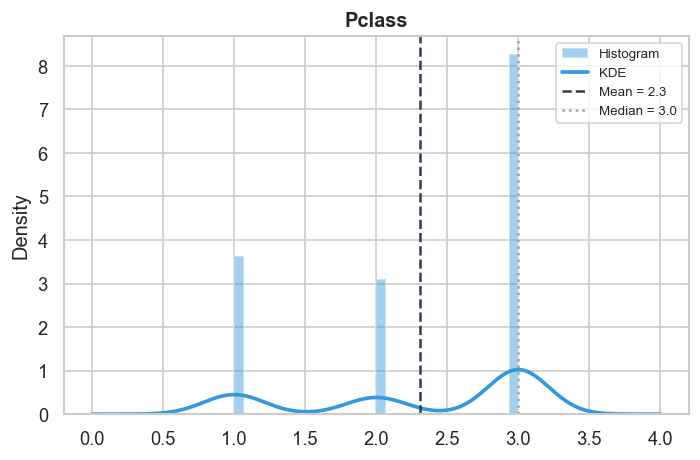

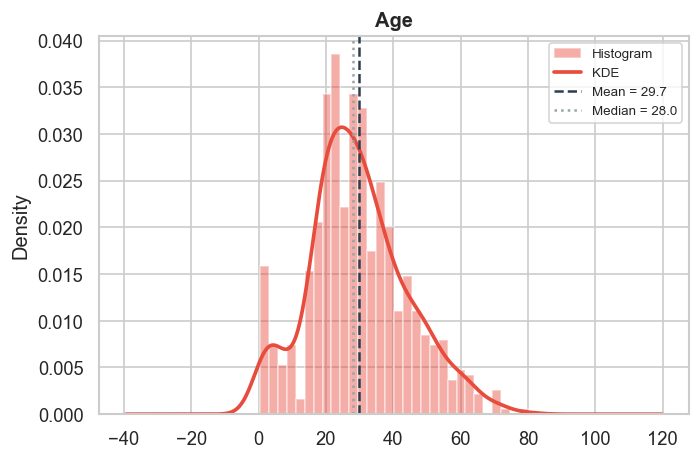

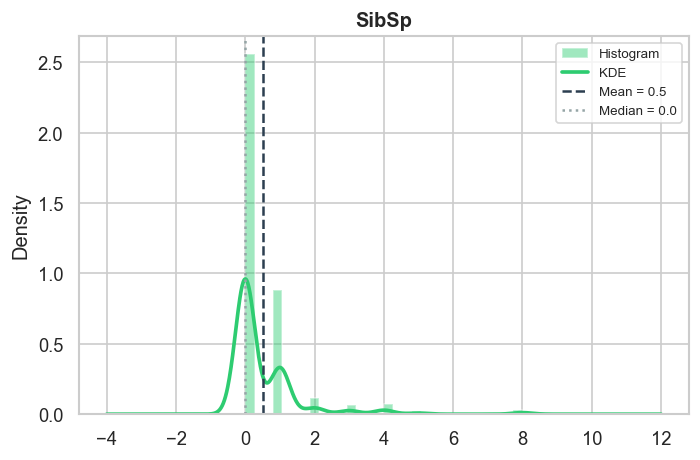

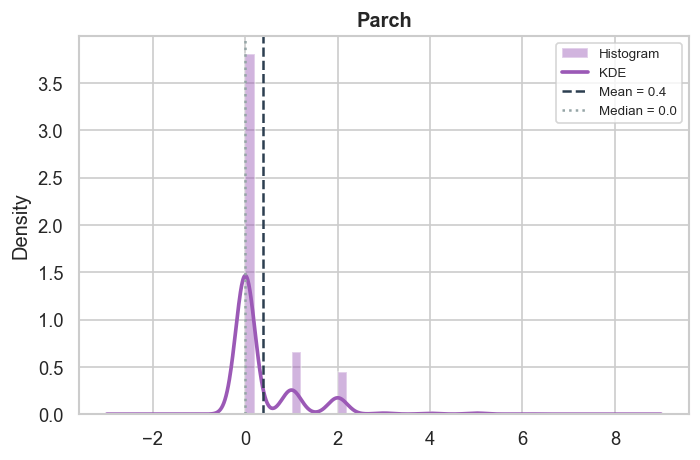

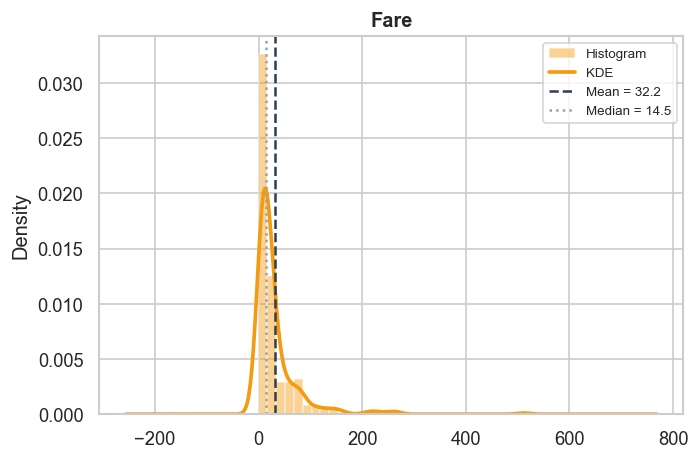

In [14]:
# ── Cell 14: Histograms + KDE — Distribution Overview ────────────────────────
COLORS = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for i, col in enumerate(num_cols):
    color = COLORS[i % len(COLORS)]
    
    data = df[col].dropna()

    plt.figure(figsize=(6,4))
    
    plt.hist(data, bins=30, color=color, alpha=0.45, edgecolor='white',
             density=True, label='Histogram')
    
    data.plot.kde(color=color, linewidth=2.2, label='KDE')
    
    plt.axvline(data.mean(), color='#2c3e50', linestyle='--',
                linewidth=1.5, label=f'Mean = {data.mean():.1f}')
    
    plt.axvline(data.median(), color='#95a5a6', linestyle=':',
                linewidth=1.5, label=f'Median = {data.median():.1f}')

    plt.title(col, fontsize=12, fontweight='bold')
    plt.legend(fontsize=8)

    plt.tight_layout()
    
    # Save each figure (optional but recommended)
    plt.savefig(f"{col}_distribution.png", dpi=300, bbox_inches="tight")
    
    plt.show()

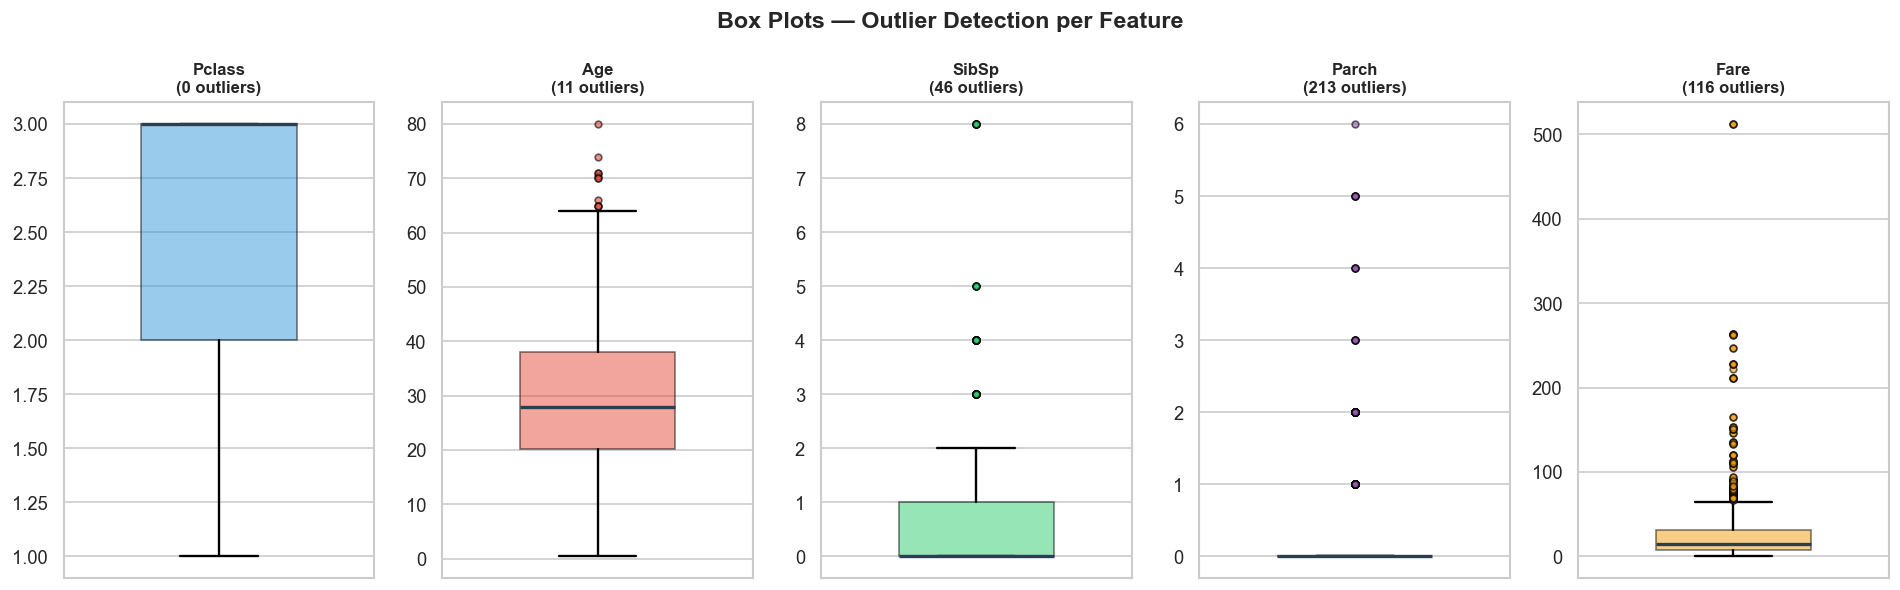

In [15]:
# ── Cell 15: Box Plots — Outlier Detection ────────────────────────────────────
fig, axes = plt.subplots(1, len(num_cols), figsize=(3.2 * len(num_cols), 5))

for ax, col, color in zip(axes, num_cols, COLORS):
    data = df[col].dropna()

    ax.boxplot(
        data, patch_artist=True, widths=0.5,
        boxprops=dict(facecolor=color, alpha=0.5),
        medianprops=dict(color='#2c3e50', linewidth=2),
        flierprops=dict(marker='o', markerfacecolor=color,
                        markersize=4, alpha=0.6, linestyle='none'),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4)
    )

    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.set_title(f'{col}\n({n_out} outliers)', fontsize=10, fontweight='bold')
    ax.set_xticks([])

fig.suptitle('Box Plots — Outlier Detection per Feature',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

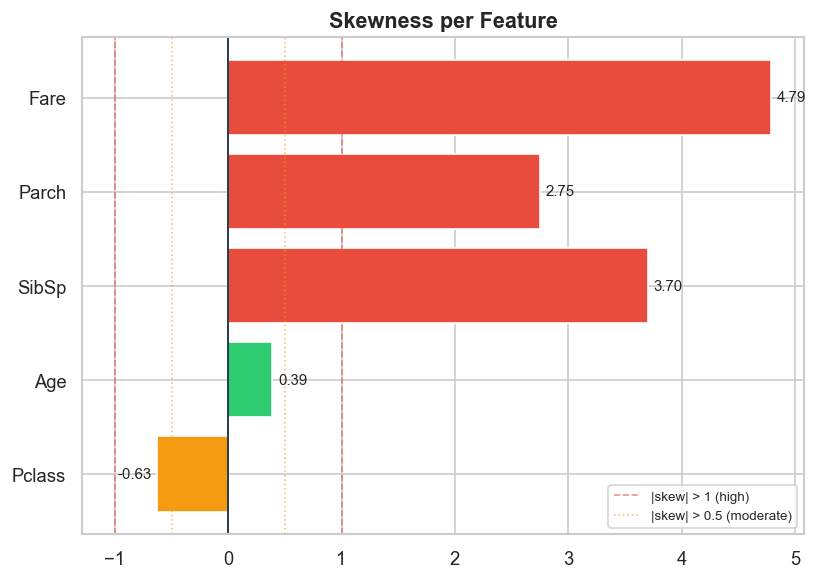

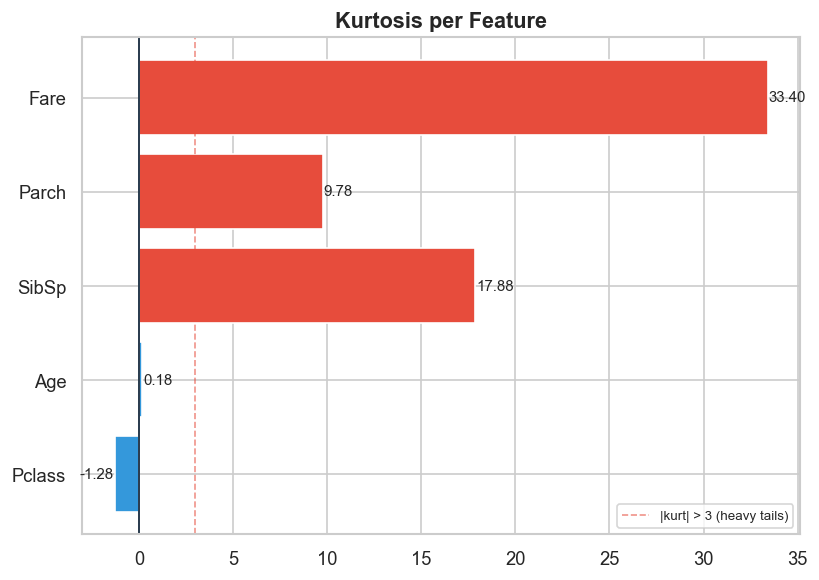

In [39]:
# ── Cell 16: Skewness & Kurtosis Bar Charts ──────────────────────────────────

skew_vals = stats_df['Skewness']
kurt_vals = stats_df['Kurtosis']


# ==============================
# Skewness Plot
# ==============================
plt.figure(figsize=(7,5))

skew_colors = [
    '#e74c3c' if abs(v) > 1
    else '#f39c12' if abs(v) > 0.5
    else '#2ecc71'
    for v in skew_vals
]

plt.barh(skew_vals.index, skew_vals.values, color=skew_colors, edgecolor='white')

plt.axvline(0, color='#2c3e50', linewidth=1.2)
plt.axvline(1, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.6, label='|skew| > 1 (high)')
plt.axvline(-1, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.6)
plt.axvline(0.5, color='#f39c12', linewidth=1, linestyle=':', alpha=0.6, label='|skew| > 0.5 (moderate)')
plt.axvline(-0.5, color='#f39c12', linewidth=1, linestyle=':', alpha=0.6)

for i, v in enumerate(skew_vals.values):
    plt.text(
        v + (0.05 if v >= 0 else -0.05),
        i,
        f'{v:.2f}',
        va='center',
        ha='left' if v >= 0 else 'right',
        fontsize=9
    )

plt.title('Skewness per Feature', fontsize=13, fontweight='bold')
plt.legend(fontsize=8)

plt.tight_layout()
plt.savefig("skewness_features.png", dpi=300, bbox_inches="tight")
plt.show()



# ==============================
# Kurtosis Plot
# ==============================
plt.figure(figsize=(7,5))

kurt_colors = [
    '#e74c3c' if abs(v) > 3 else '#3498db'
    for v in kurt_vals
]

plt.barh(kurt_vals.index, kurt_vals.values, color=kurt_colors, edgecolor='white')

plt.axvline(0, color='#2c3e50', linewidth=1.2)
plt.axvline(3, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.6, label='|kurt| > 3 (heavy tails)')
plt.axvline(-3, color='#e74c3c', linewidth=1, linestyle='--', alpha=0.6)

for i, v in enumerate(kurt_vals.values):
    plt.text(
        v + (0.05 if v >= 0 else -0.05),
        i,
        f'{v:.2f}',
        va='center',
        ha='left' if v >= 0 else 'right',
        fontsize=9
    )

plt.title('Kurtosis per Feature', fontsize=13, fontweight='bold')
plt.legend(fontsize=8)

plt.tight_layout()
plt.savefig("kurtosis_features.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
# ── Cell 17: Outlier Summary Table  ──────────────────────────────
outlier_rows = []
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lower) | (s > upper)).sum()
    pct_out = round(n_out / len(s) * 100, 2)

    if pct_out >= 5:
        severity = '🔴 High'
    elif pct_out >= 1:
        severity = '🟡 Medium'
    else:
        severity = '🟢 Low'

    outlier_rows.append({
        'Column'        : col,
        'Lower Fence'   : round(lower, 2),
        'Upper Fence'   : round(upper, 2),
        'Outlier Count' : n_out,
        'Outlier %'     : pct_out,
        'Severity'      : severity
    })

outlier_df = pd.DataFrame(outlier_rows).set_index('Column')
outlier_df

,Lower Fence,Upper Fence,Outlier Count,Outlier %,Severity
Column,,,,,
Pclass,0.50,4.50,0,0.00,🟢 Low
Age,-6.69,64.81,11,1.54,🟡 Medium
SibSp,-1.50,2.50,46,5.16,🔴 High
Parch,0.00,0.00,213,23.91,🔴 High
Fare,-26.72,65.63,116,13.02,🔴 High


# 4. Categorical Features Analysis

In [18]:
# ── Cell 18: Identify category Columns  ────────────────────────────────────────────
print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')

Categorical columns (5): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [19]:
# ── Cell 19: Cardinality Classification ──────────────────────────────────────

def classify_cardinality(nunique, n_rows):
    ratio = nunique / n_rows
    if nunique <= 2:
        return '🟢 Binary'
    elif nunique <= 10:
        return '🟡 Low'
    elif ratio >= 0.5:
        return '🔴 High (ID-like)'
    else:
        return '🟠 Medium'

card_rows = []
for col in cat_cols:
    nunique   = df[col].nunique()
    mode_val  = df[col].mode()[0]
    mode_freq = df[col].value_counts().iloc[0]
    mode_pct  = round(mode_freq / df[col].notna().sum() * 100, 2)
    missing   = round(df[col].isnull().mean() * 100, 2)
    card_rows.append({
        'Column'       : col,
        'Unique Values': nunique,
        'Cardinality'  : classify_cardinality(nunique, len(df)),
        'Mode'         : mode_val,
        'Mode Freq'    : mode_freq,
        'Mode %'       : mode_pct,
        'Missing %'    : missing
    })

card_df = pd.DataFrame(card_rows).set_index('Column')
card_df

,Unique Values,Cardinality,Mode,Mode Freq,Mode %,Missing %
Column,,,,,,
Name,891,🔴 High (ID-like),"Abbing, Mr. Anthony",1,0.11,0.00
Sex,2,🟢 Binary,male,577,64.76,0.00
Ticket,681,🔴 High (ID-like),1601,7,0.79,0.00
Cabin,147,🟠 Medium,B96 B98,4,1.96,77.10
Embarked,3,🟡 Low,S,644,72.44,0.22


In [20]:
# ── Cell 20: Focus on Analysable Columns ─────────────────────────────────────
# Drop high-cardinality ID-like columns from frequency analysis

high_card_threshold = 0.5   # >50% unique values → skip
analyse_cat_cols = [
    c for c in cat_cols
    if df[c].nunique() / len(df) < high_card_threshold
]

skipped = [c for c in cat_cols if c not in analyse_cat_cols]
print(f'Columns to analyse  : {analyse_cat_cols}')
print(f'Skipped (high-card) : {skipped}')

Columns to analyse  : ['Sex', 'Cabin', 'Embarked']
Skipped (high-card) : ['Name', 'Ticket']


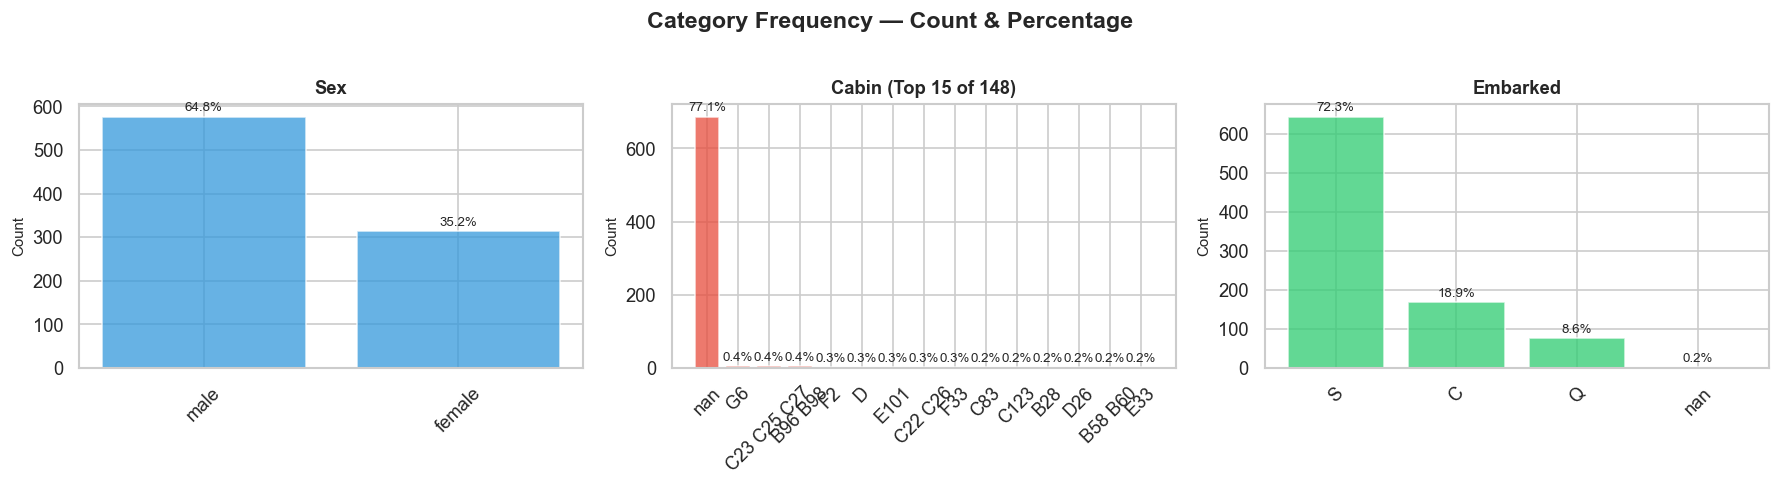

In [21]:
# ── Cell 21: Frequency Bar Charts — Count + Percentage ───────────────────────
COLORS_CAT = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
TOP_N = 15   # limit for high-cardinality columns

ncols = 3
nrows = -(-len(analyse_cat_cols) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, (col, color) in enumerate(zip(analyse_cat_cols, COLORS_CAT)):
    ax = axes[i]
    vc_full = df[col].value_counts(dropna=False)

    # Limit to TOP_N if too many unique values
    is_truncated = len(vc_full) > TOP_N
    vc = vc_full.head(TOP_N) if is_truncated else vc_full
    pct = vc / vc_full.sum() * 100   # pct relative to full column

    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=color, alpha=0.75, edgecolor='white')

    # Annotate each bar with percentage
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + vc.max() * 0.01,
                f'{p:.1f}%', ha='center', va='bottom', fontsize=8)

    title = f'{col} (Top {TOP_N} of {len(vc_full)})' if is_truncated else col
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Category Frequency — Count & Percentage',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

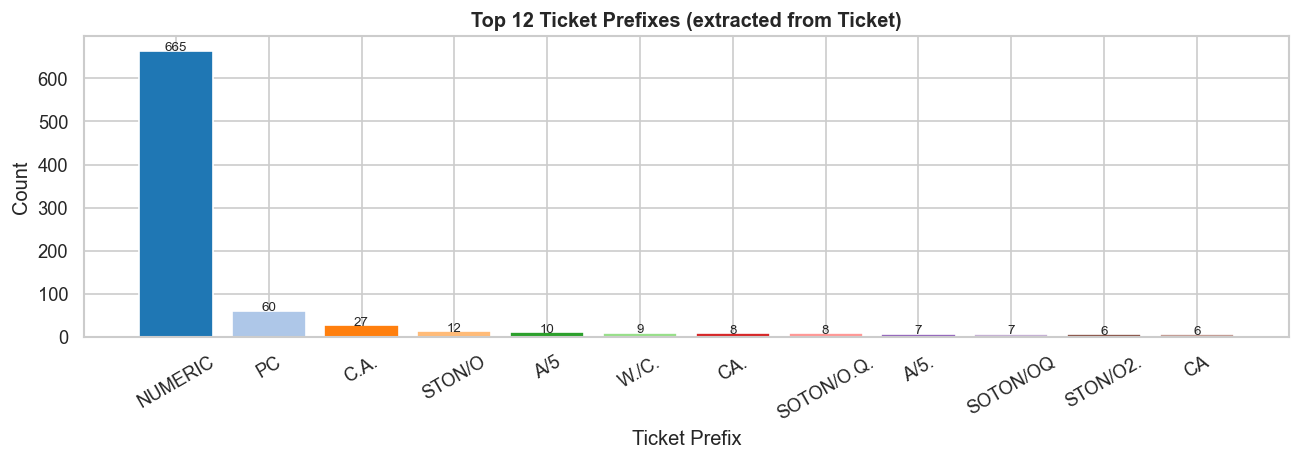

In [22]:
# ── Cell 22: Ticket Prefix Extraction ───────────────────────────────────────
# Ticket is high-cardinality but many share a prefix — extract it

def extract_ticket_prefix(ticket):
    parts = ticket.strip().split()
    if len(parts) > 1:
        return parts[0]        # e.g. 'PC', 'STON/O2.'
    return 'NUMERIC'           # pure numeric ticket

df['Ticket_Prefix'] = df['Ticket'].apply(extract_ticket_prefix)

top_prefixes = df['Ticket_Prefix'].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(top_prefixes.index, top_prefixes.values,
              color=sns.color_palette('tab20', len(top_prefixes)),
              edgecolor='white')
for bar, val in zip(bars, top_prefixes.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=8)
ax.set_title('Top 12 Ticket Prefixes (extracted from Ticket)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ticket Prefix')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

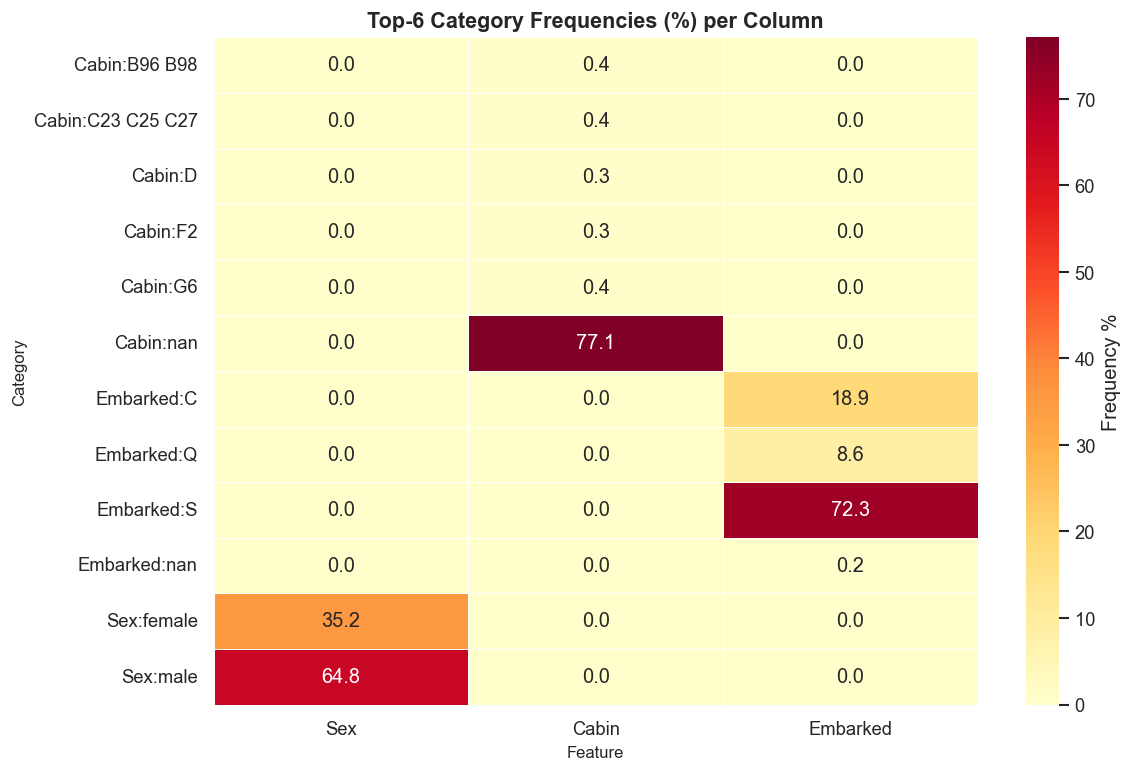

In [23]:
# ── Cell 23: Heatmap — Category Frequency as % (multi-col overview) ──────────
# For each analysable column, show normalised value counts side-by-side

# Build a padded matrix: rows = rank position, cols = categorical features
top_n = 6
heat_data = {}

for col in analyse_cat_cols:
    vc = df[col].value_counts(normalize=True, dropna=False).head(top_n) * 100
    vc.index = [f'{col}:{str(idx)}'for idx in vc.index]
    heat_data[col] = vc

heat_df = pd.DataFrame(heat_data).fillna(0)

fig, ax = plt.subplots(figsize=(10, max(4, len(heat_df) * 0.55)))
sns.heatmap(
    heat_df, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Frequency %'},
    ax=ax
)
ax.set_title(f'Top-{top_n} Category Frequencies (%) per Column',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=10)
ax.set_ylabel('Category', fontsize=10)
plt.tight_layout()
plt.show()

In [24]:
# ── Cell 24: Categorical Summary Table ──────────────────────────────────────
summary_rows = []
for col in cat_cols:
    vc = df[col].value_counts(dropna=True)
    nunique   = df[col].nunique()
    mode_val  = vc.index[0]
    mode_pct  = round(vc.iloc[0] / df[col].notna().sum() * 100, 2)
    missing   = round(df[col].isnull().mean() * 100, 2)
    card_type = classify_cardinality(nunique, len(df))

    if nunique == len(df):                      # every value is unique → pure ID
        action = 'Drop (fully unique, no signal)'
    elif nunique / len(df) >= 0.5:              # >50% unique but not fully → maybe engineer
        action = 'Engineer or Drop (high cardinality)'
    elif missing > 40:                          # too much missing data
        action = 'Extract features or drop'
    elif nunique <= 2:                          # binary
        action = 'Ready — encode as 0/1'
    else:                                       # low cardinality, clean enough
        action = 'Ready — one-hot / ordinal encode'

    summary_rows.append({
        'Column'      : col,
        'Unique'      : nunique,
        'Cardinality' : card_type,
        'Mode'        : mode_val,
        'Mode %'      : mode_pct,
        'Missing %'   : missing,
        'Action'      : action
    })

summary_df = pd.DataFrame(summary_rows).set_index('Column')
summary_df

,Unique,Cardinality,Mode,Mode %,Missing %,Action
Column,,,,,,
Name,891,🔴 High (ID-like),"Dooley, Mr. Patrick",0.11,0.00,"Drop (fully unique, no signal)"
Sex,2,🟢 Binary,male,64.76,0.00,Ready — encode as 0/1
Ticket,681,🔴 High (ID-like),347082,0.79,0.00,Engineer or Drop (high cardinality)
Cabin,147,🟠 Medium,G6,1.96,77.10,Extract features or drop
Embarked,3,🟡 Low,S,72.44,0.22,Ready — one-hot / ordinal encode


# 5. Correlation Analysis

In [25]:
# ── Cell 25: Pearson Correlation Matrix (Numerical Features) ───────────────────────────────────────
corr_matrix = df[num_cols].corr(method='pearson')

print('Pearson Correlation Matrix:')
corr_matrix.round(3)

Pearson Correlation Matrix:


,Pclass,Age,SibSp,Parch,Fare
Pclass,1.000,-0.369,0.083,0.018,-0.549
Age,-0.369,1.000,-0.308,-0.189,0.096
SibSp,0.083,-0.308,1.000,0.415,0.160
Parch,0.018,-0.189,0.415,1.000,0.216
Fare,-0.549,0.096,0.160,0.216,1.000


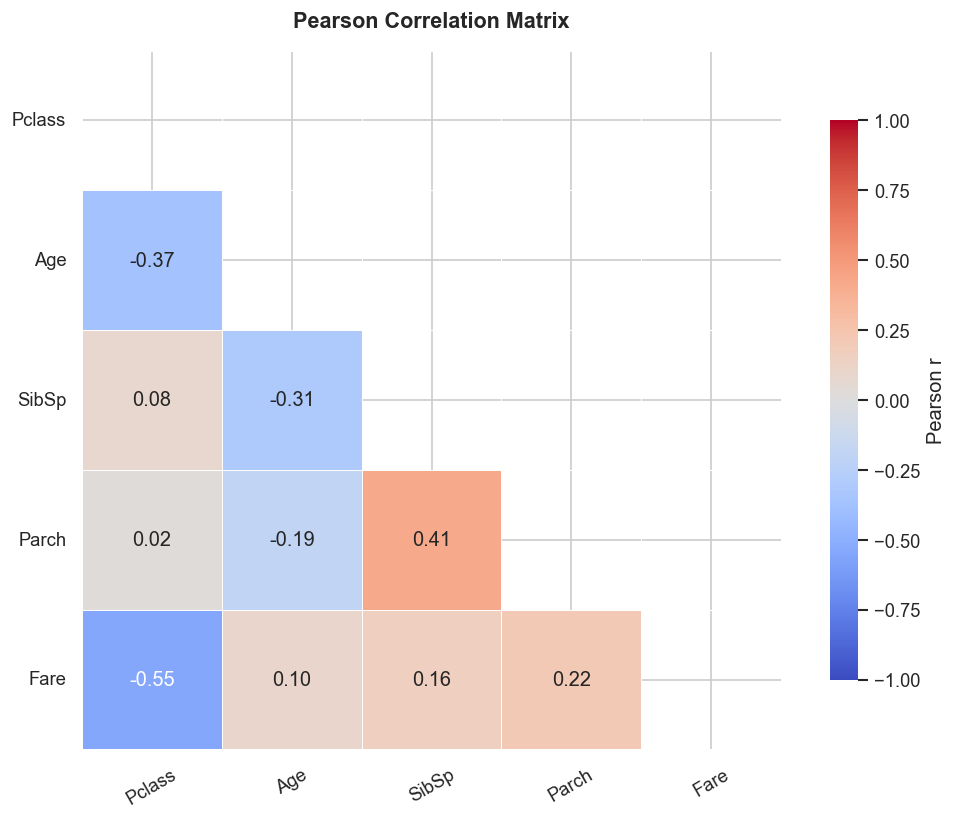

In [26]:
# ── Cell 26: Heatmap — Full Correlation Matrix ────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
    ax=ax
)

ax.set_title('Pearson Correlation Matrix',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# ── Cell 27: Top Correlated Pairs  ───────────────────────────────────
def get_corr_pairs(matrix, method_name):
    pairs = []
    cols = matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = matrix.iloc[i, j]
            pairs.append({
                'Feature A' : cols[i],
                'Feature B' : cols[j],
                f'{method_name} r' : round(r, 4),
                '|r|'       : round(abs(r), 4)
            })
    return pd.DataFrame(pairs).sort_values('|r|', ascending=False)

pairs_df = get_corr_pairs(corr_matrix, 'Pearson')

def label_strength(r):
    a = abs(r)
    if a >= 0.7:  return '🔴 Strong'
    if a >= 0.4:  return '🟡 Moderate'
    if a >= 0.2:  return '🟢 Weak'
    return '⚪ Negligible'

pairs_df['Strength'] = pairs_df['Pearson r'].apply(label_strength)
pairs_df = pairs_df.reset_index(drop=True)
pairs_df

,Feature A,Feature B,Pearson r,|r|,Strength
0,Pclass,Fare,-0.5495,0.5495,🟡 Moderate
1,SibSp,Parch,0.4148,0.4148,🟡 Moderate
2,Pclass,Age,-0.3692,0.3692,🟢 Weak
3,Age,SibSp,-0.3082,0.3082,🟢 Weak
4,Parch,Fare,0.2162,0.2162,🟢 Weak
5,Age,Parch,-0.1891,0.1891,⚪ Negligible
6,SibSp,Fare,0.1597,0.1597,⚪ Negligible
7,Age,Fare,0.0961,0.0961,⚪ Negligible
8,Pclass,SibSp,0.0831,0.0831,⚪ Negligible
9,Pclass,Parch,0.0184,0.0184,⚪ Negligible


# 6. Target Analysis

In [ ]:
# ── Cell 28: Class Balance — Count & Proportion ───────────────────────────────
target       = 'Survived'
num_features = [c for c in num_cols if c not in ['PassengerId', target]]
cat_features = [c for c in cat_cols if c not in ['Name', 'Ticket', 'Cabin']]
survived_vc  = df[target].value_counts().sort_index()
survived_pct = df[target].value_counts(normalize=True).sort_index() * 100

print('Class Distribution:')
balance_df = pd.DataFrame({
    'Label'  : ['Did Not Survive', 'Survived'],
    'Count'  : survived_vc.values,
    'Percent': survived_pct.round(2).values
})
print(balance_df.to_string(index=False))

ratio = survived_vc[0] / survived_vc[1]
print(f'\nImbalance ratio (0:1) = {ratio:.2f}:1')
if ratio > 3:
    print('⚠️  Severe imbalance')
elif ratio > 1.5:
    print('🟡 Moderate imbalance')
else:
    print('🟢 Roughly balanced')

['Sex', 'Embarked']
Class Distribution:
          Label  Count  Percent
Did Not Survive    549    61.62
       Survived    342    38.38

Imbalance ratio (0:1) = 1.61:1
🟡 Moderate imbalance


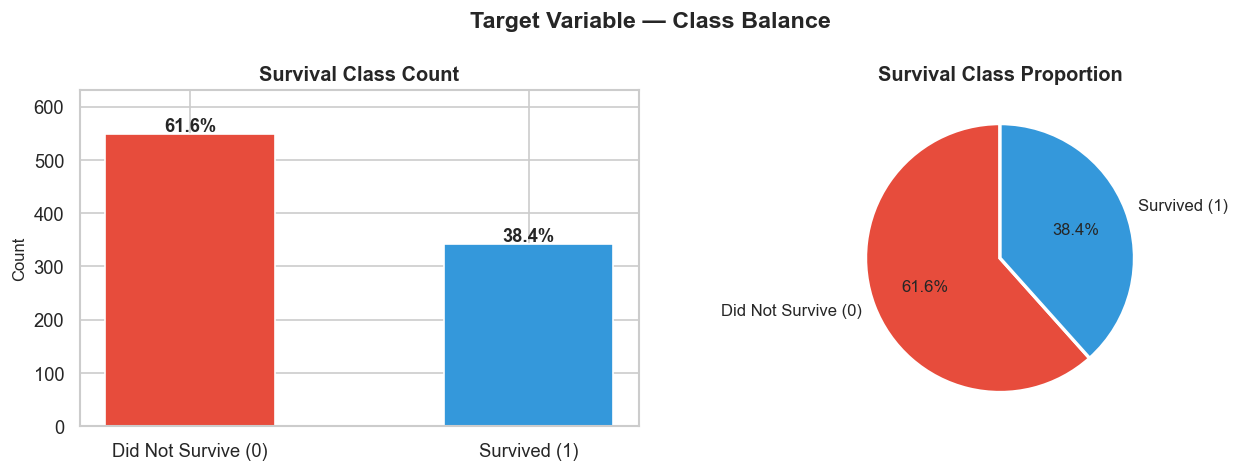

In [29]:
# ── Cell 29: Class Balance Visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
PALETTE = ['#e74c3c', '#3498db']
LABELS  = ['Did Not Survive (0)', 'Survived (1)']

# --- Bar chart
bars = axes[0].bar(LABELS, survived_vc.values, color=PALETTE, edgecolor='white', width=0.5)
for bar, pct in zip(bars, survived_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_title('Survival Class Count', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, survived_vc.max() * 1.15)

# --- Pie chart
axes[1].pie(
    survived_vc.values, labels=LABELS,
    autopct='%1.1f%%', colors=PALETTE,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(fontsize=10)
)
axes[1].set_title('Survival Class Proportion', fontsize=12, fontweight='bold')

fig.suptitle('Target Variable — Class Balance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# ── Cell 30: Correlation of Numerical Features with Target ────────────────────
target_corr_rows = []
for col in num_features:
    tmp = df[[col, target]].dropna()
    pb_r,  pb_p  = pointbiserialr(tmp[target], tmp[col])
    sp_r,  sp_p  = spearmanr(tmp[col], tmp[target])
    target_corr_rows.append({
        'Feature'          : col,
        'Point-Biserial r' : round(pb_r, 4),
        'Spearman r'       : round(sp_r, 4),
        '|r|'              : round(abs(pb_r), 4),
        'p-value'          : round(pb_p, 4),
        'Significant'      : '✅' if pb_p < 0.05 else '❌'
    })

target_corr_df = (pd.DataFrame(target_corr_rows)
                    .sort_values('|r|', ascending=False)
                    .reset_index(drop=True))
target_corr_df

,Feature,Point-Biserial r,Spearman r,|r|,p-value,Significant
0,Pclass,-0.3385,-0.3397,0.3385,0.0000,✅
1,Fare,0.2573,0.3237,0.2573,0.0000,✅
2,Parch,0.0816,0.1383,0.0816,0.0148,✅
3,Age,-0.0772,-0.0526,0.0772,0.0391,✅
4,SibSp,-0.0353,0.0889,0.0353,0.2922,❌


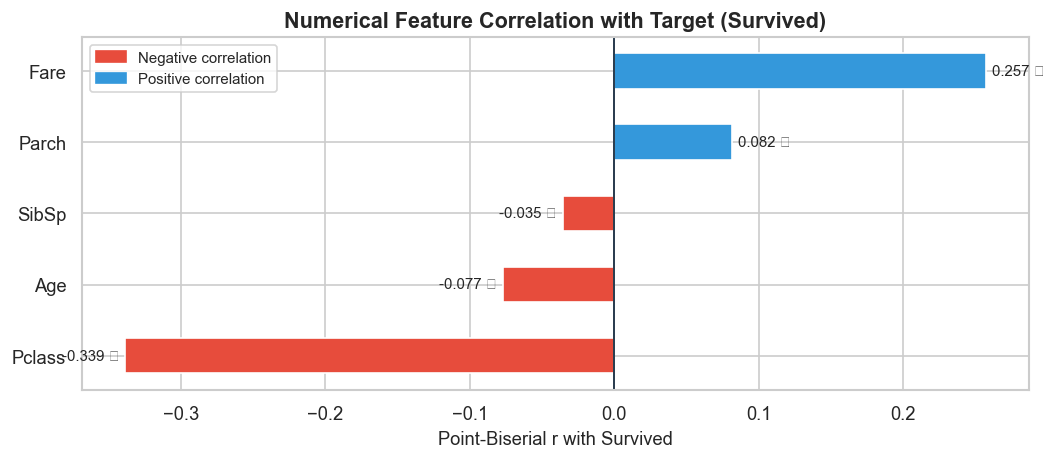

In [31]:
# ── Cell 31: Bar Chart — Numerical Feature Correlation with Target ────────────
sorted_df = target_corr_df.sort_values('Point-Biserial r')

bar_colors = ['#e74c3c' if r < 0 else '#3498db'
              for r in sorted_df['Point-Biserial r']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(sorted_df['Feature'], sorted_df['Point-Biserial r'],
               color=bar_colors, edgecolor='white', height=0.5)

for bar, val, sig in zip(bars, sorted_df['Point-Biserial r'], sorted_df['Significant']):
    offset = 0.004 if val >= 0 else -0.004
    ha = 'left' if val >= 0 else 'right'
    label = f'{val:.3f} {sig}'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            label, va='center', ha=ha, fontsize=9)

ax.axvline(0, color='#2c3e50', linewidth=1.2)
ax.set_xlabel('Point-Biserial r with Survived', fontsize=11)
ax.set_title('Numerical Feature Correlation with Target (Survived)',
             fontsize=13, fontweight='bold')

neg_patch = mpatches.Patch(color='#e74c3c', label='Negative correlation')
pos_patch = mpatches.Patch(color='#3498db', label='Positive correlation')
ax.legend(handles=[neg_patch, pos_patch], fontsize=9)
plt.tight_layout()
plt.show()

['Sex', 'Embarked']


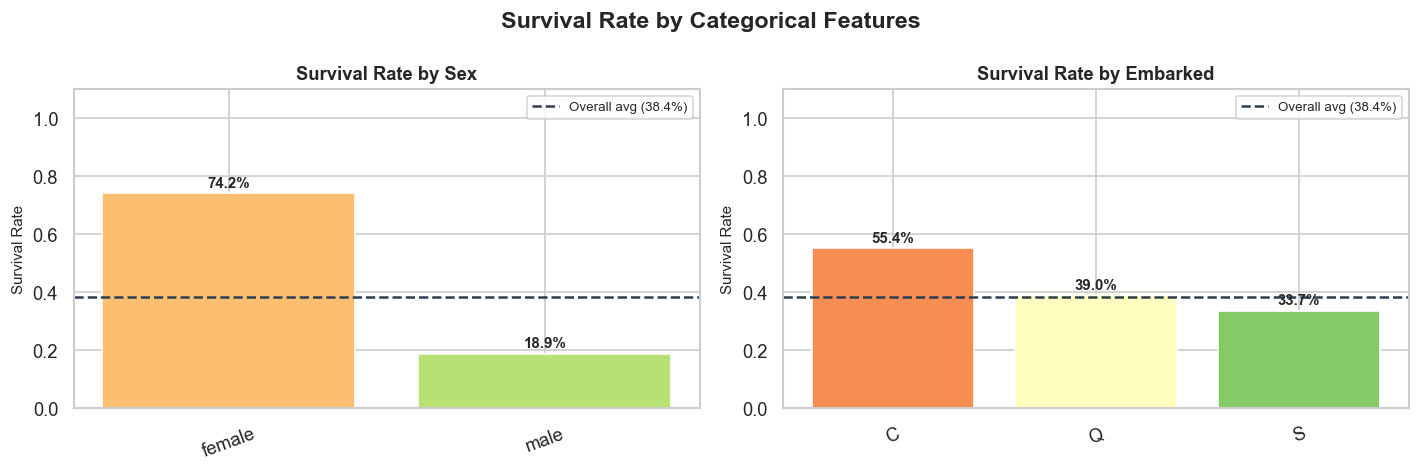

In [ ]:
# ── Cell 32: Survival Rate by Categorical Features ────────────────────────────
ncols = len(cat_features)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 4))

if ncols == 1:
    axes = [axes]

for ax, col in zip(axes, cat_features):
    surv_rate = (df.groupby(col)[target]
                   .mean()
                   .sort_values(ascending=False)
                   .reset_index())
    surv_rate.columns = [col, 'Survival Rate']
    surv_rate['Survival Rate %'] = (surv_rate['Survival Rate'] * 100).round(1)

    palette = sns.color_palette('RdYlGn', len(surv_rate))
    bars = ax.bar(surv_rate[col].astype(str),
                  surv_rate['Survival Rate'],
                  color=palette, edgecolor='white')

    for bar, pct in zip(bars, surv_rate['Survival Rate %']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{pct}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.axhline(df[target].mean(), color='#2c3e50', linewidth=1.5,
               linestyle='--', label=f'Overall avg ({df[target].mean()*100:.1f}%)')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Survival Rate', fontsize=9)
    ax.set_title(f'Survival Rate by {col}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Survival Rate by Categorical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

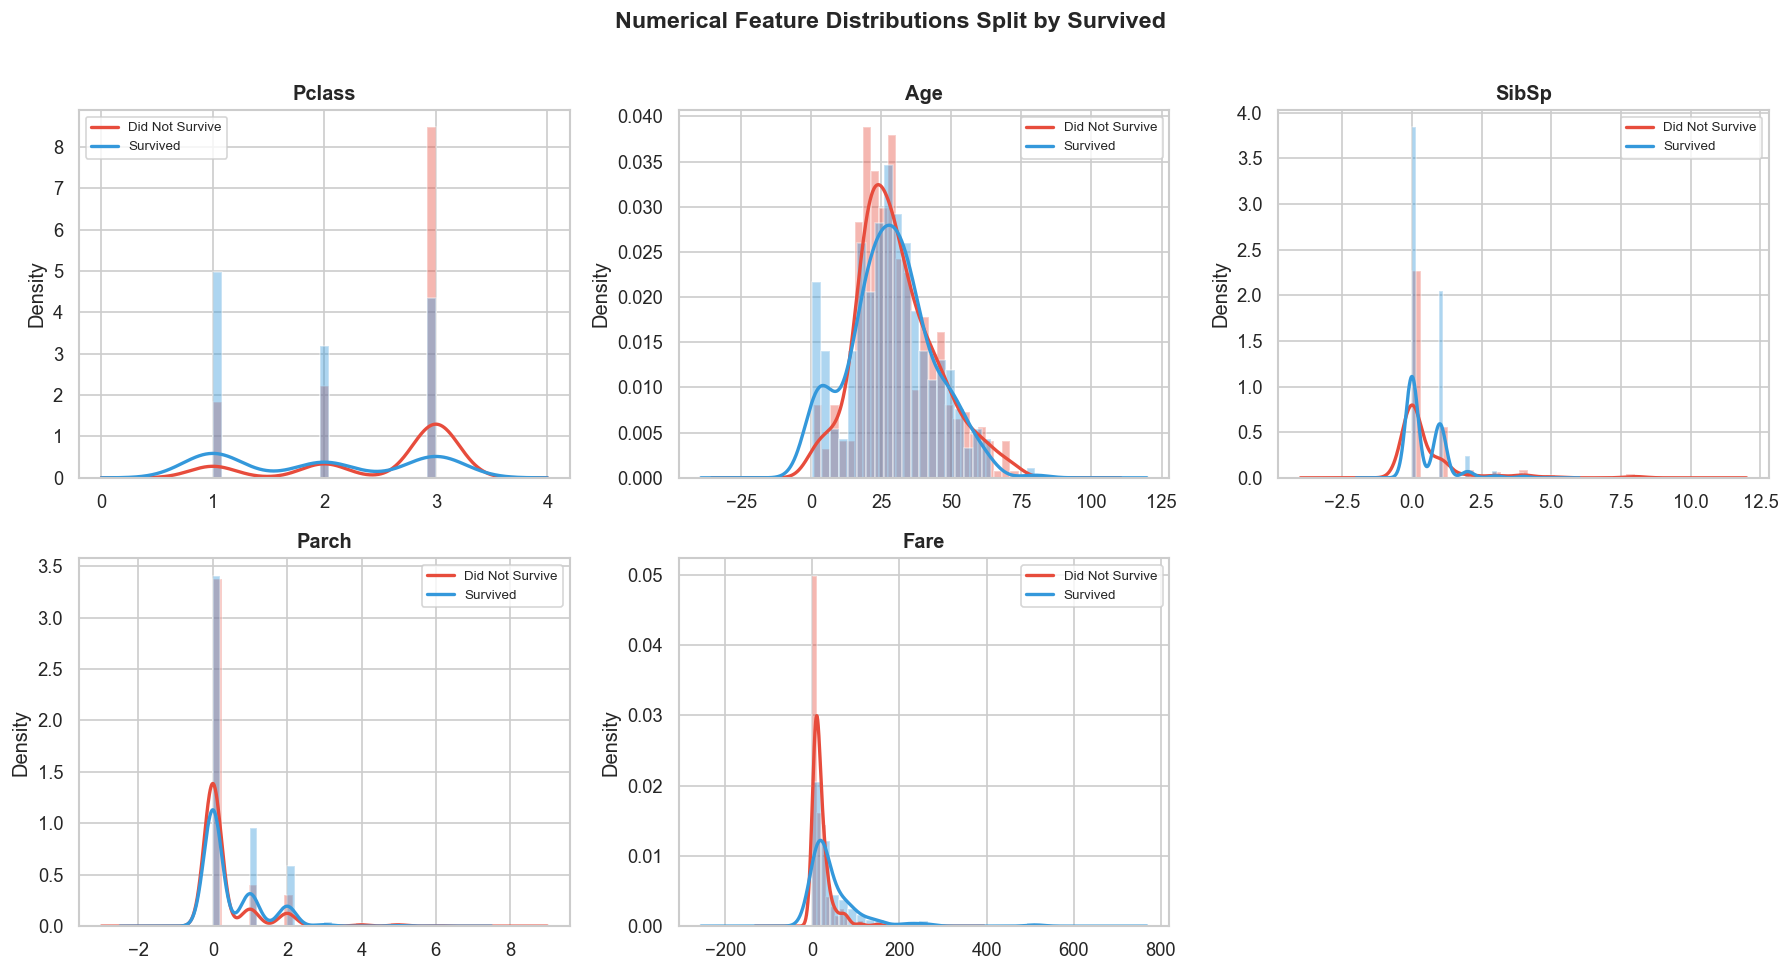

In [33]:
# ── Cell 33: Numerical Features — Distribution by Survived ───────────────────

ncols = 3
nrows = -(-len(num_features) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_features):
    ax = axes[i]
    for val, label, color in zip([0, 1],
                                  ['Did Not Survive', 'Survived'],
                                  ['#e74c3c', '#3498db']):
        data = df[df[target] == val][col].dropna()
        ax.hist(data, bins=25, alpha=0.4, color=color,
                density=True, edgecolor='white', label=f'_{label}')
        data.plot.kde(ax=ax, color=color, linewidth=2, label=label)

    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numerical Feature Distributions Split by Survived',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

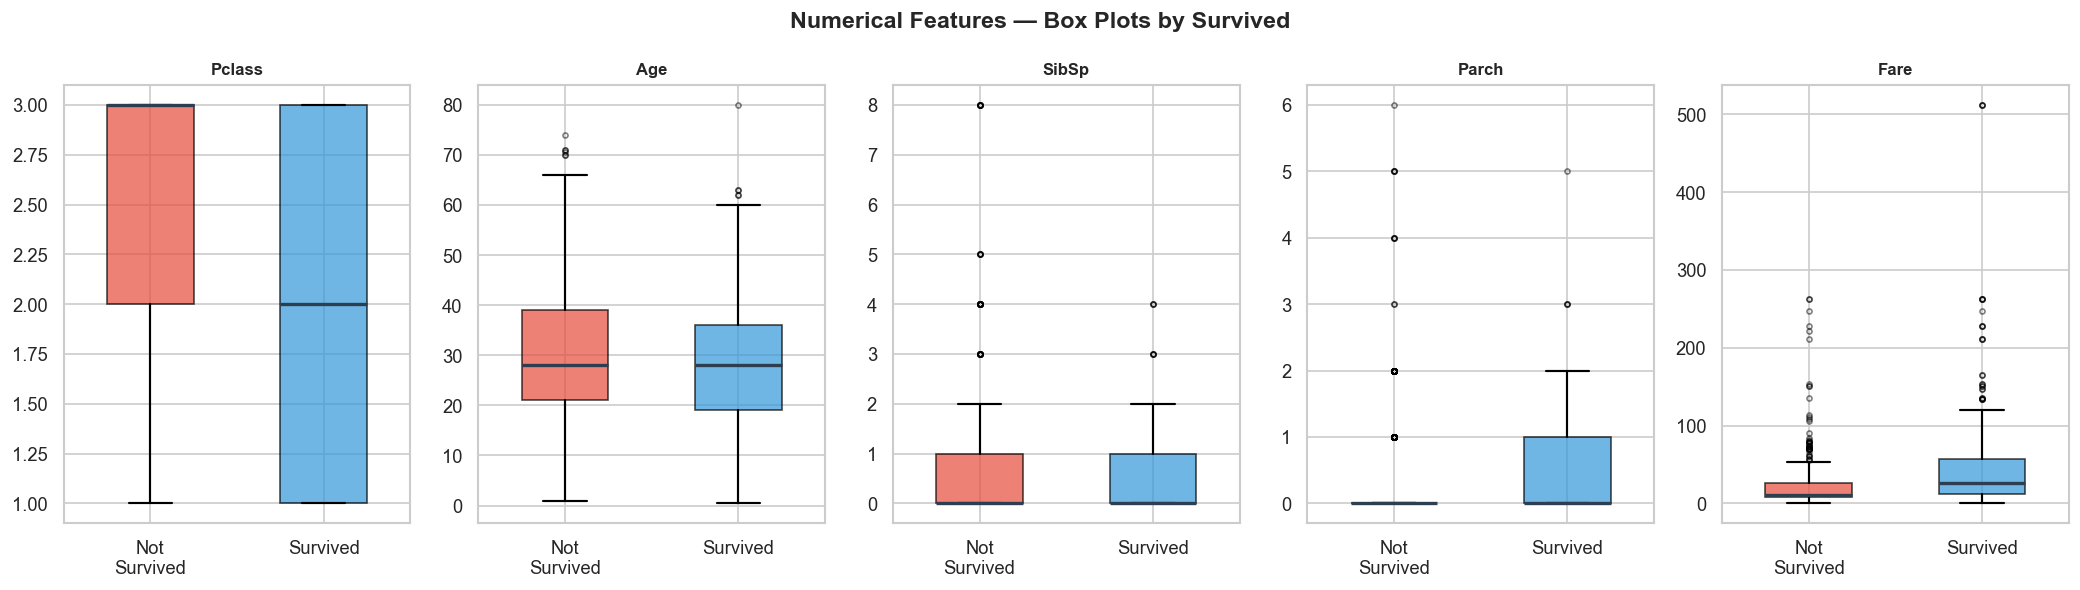

In [34]:
# ── Cell 34: Box Plots — Numerical Features by Survived ──────────────────────
fig, axes = plt.subplots(1, len(num_features),
                         figsize=(3.5 * len(num_features), 5))

for ax, col in zip(axes, num_features):
    data_0 = df[df[target] == 0][col].dropna()
    data_1 = df[df[target] == 1][col].dropna()

    bp = ax.boxplot(
        [data_0, data_1],
        patch_artist=True,
        widths=0.5,
        labels=['Not\nSurvived', 'Survived'],
        boxprops=dict(alpha=0.7),
        medianprops=dict(color='#2c3e50', linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.5, linestyle='none'),
        whiskerprops=dict(linewidth=1.3),
        capprops=dict(linewidth=1.3)
    )
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#3498db')

    ax.set_title(col, fontsize=10, fontweight='bold')

fig.suptitle('Numerical Features — Box Plots by Survived',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

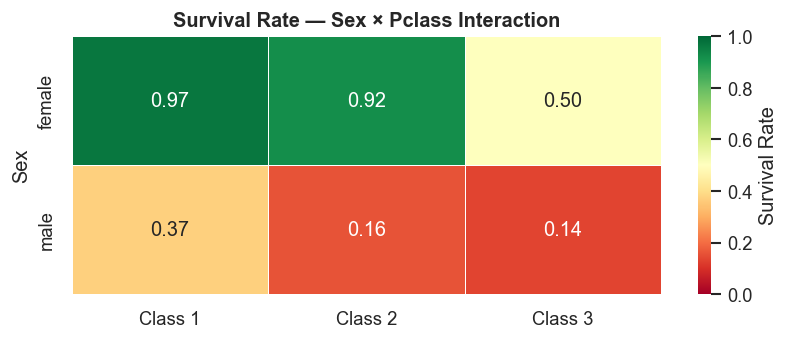

In [35]:
# ── Cell 35: Heatmap — Survival Rate by Two Categorical Features ─────────────
# Pivot table: Sex × Pclass — reveals interaction effects

pivot = df.pivot_table(values=target, index='Sex', columns='Pclass', aggfunc='mean')
pivot.columns = [f'Class {c}' for c in pivot.columns]

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Survival Rate'},
    ax=ax
)
ax.set_title('Survival Rate — Sex × Pclass Interaction',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

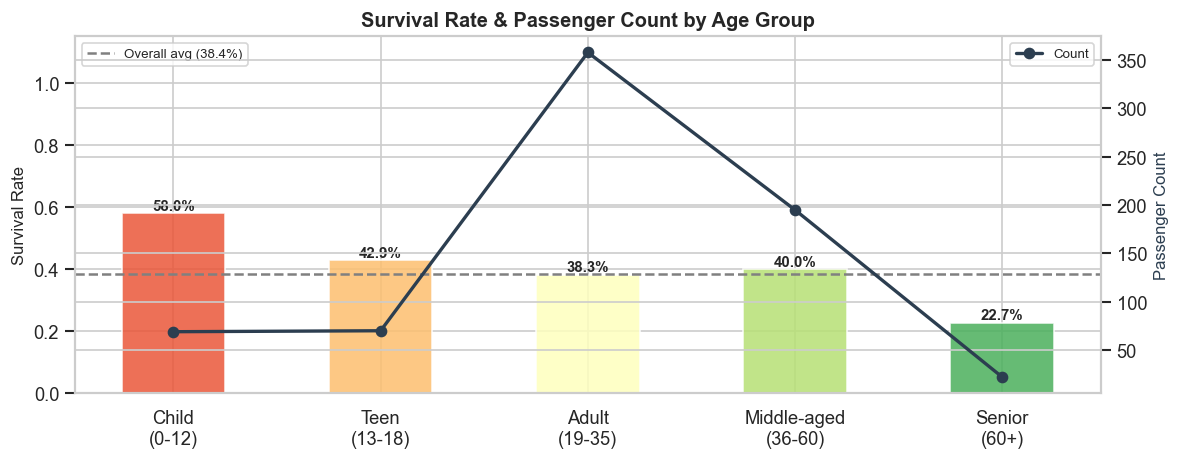

In [36]:
# ── Cell 36: Age Bins — Survival Rate by Age Group ───────────────────────────
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child\n(0-12)', 'Teen\n(13-18)', 'Adult\n(19-35)',
            'Middle-aged\n(36-60)', 'Senior\n(60+)']
)

age_surv = (df.groupby('Age_Group', observed=True)[target]
              .agg(['mean', 'count'])
              .reset_index())
age_surv.columns = ['Age_Group', 'Survival Rate', 'Count']

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

palette = sns.color_palette('RdYlGn', len(age_surv))
bars = ax1.bar(age_surv['Age_Group'].astype(str),
               age_surv['Survival Rate'],
               color=palette, edgecolor='white', alpha=0.85, width=0.5)
ax2.plot(age_surv['Age_Group'].astype(str), age_surv['Count'],
         color='#2c3e50', marker='o', linewidth=2, label='Count')

for bar, pct in zip(bars, age_surv['Survival Rate']):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{pct*100:.1f}%', ha='center', fontsize=9, fontweight='bold')

ax1.axhline(df[target].mean(), color='grey', linewidth=1.5,
            linestyle='--', label=f'Overall avg ({df[target].mean()*100:.1f}%)')
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Survival Rate', fontsize=10)
ax2.set_ylabel('Passenger Count', fontsize=10, color='#2c3e50')
ax1.set_title('Survival Rate & Passenger Count by Age Group',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()